# 24. The `KMatrix` pi-pi S-wave

**Objectives:**
- Build `KMatrix`, the Laura++ / Anisovich-Sarantsev five-pole five-channel pi-pi S-wave
  K-matrix, with the default `betas`/`f_prod`.
- Look at `scattering_matrix()` and `scattering_amplitude()` (the T-matrix), then check the
  unitarity of `s_matrix()` in a mass region where all five channels are open.
- Embed the pi-pi production amplitude in a minimal one-resonance `DecayModel`, generate a
  toy, and recover a floated Cartesian coefficient with `FitSession.fit()`.

Run the cells in order in a fresh kernel. Masses are in GeV, invariants in GeV^2, and
daughter indices start at zero.

In [1]:
from dalitzplotfitter import enable_x64
enable_x64()  # Must precede numerical work: amplitudes use complex128.

import jax.numpy as jnp
import matplotlib.pyplot as plt

from dalitzplotfitter import (
    DecayChannel, DecayModel, FitSession, KMatrix, NonResonant,
    Parameter, RealImag, Resonance, generate_toy,
)
from dalitzplotfitter.dynamics.context import ResonanceContext

## 1. Five channels, five poles

`KMatrix` couples five two-body/quasi-two-body channels -- pi-pi, K-Kbar, an effective
4-pi channel, eta-eta, eta-eta' -- through five bare poles (the Anisovich-Sarantsev pole
masses/couplings are hard-coded class constants, not constructor arguments). The
constructor only exposes the production side: `betas` (five production pole coefficients)
and `f_prod` (five production slowly-varying-part coefficients), defaulting to
`betas=(1+0j, 0, 0, 0, 0)`, `f_prod=(0, 0, 0, 0, 0)` -- production purely through the first
pole, no smooth background term.

betas: ((1+0j), 0j, 0j, 0j, 0j)
f_prod: (0j, 0j, 0j, 0j, 0j)


scattering_matrix shape: (500, 5, 5)  (real, 5x5, per mass)
scattering_amplitude (T-matrix) shape: (500, 5, 5)  (complex, 5x5, per mass)


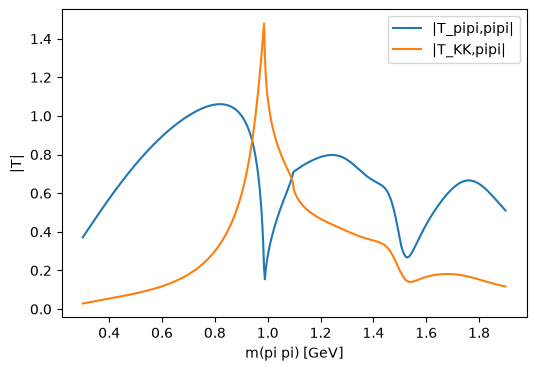

In [2]:
kmatrix = KMatrix()  # default betas/f_prod
print("betas:", kmatrix.betas)
print("f_prod:", kmatrix.f_prod)

mass_scan = jnp.linspace(0.30, 1.90, 500)
K = kmatrix.scattering_matrix(mass_scan)
T = kmatrix.scattering_amplitude(mass_scan)
print("scattering_matrix shape:", K.shape, " (real, 5x5, per mass)")
print("scattering_amplitude (T-matrix) shape:", T.shape, " (complex, 5x5, per mass)")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(mass_scan, jnp.abs(T[:, 0, 0]), label="|T_pipi,pipi|")
ax.plot(mass_scan, jnp.abs(T[:, 1, 0]), label="|T_KK,pipi|")
ax.set(xlabel="m(pi pi) [GeV]", ylabel="|T|")
ax.legend()
plt.show()

## 2. Unitarity of the S-matrix

`s_matrix()`'s docstring states it returns "the unitary 5x5 S-matrix,
`S = I + 2i*sqrt(rho) T sqrt(rho)`". That unitarity (`S S^dagger = I`) is only expected once
every channel's phase-space factor `rho(s)` is real, i.e. above all five nominal thresholds
(pi-pi, K-Kbar, the effective 4-pi channel, eta-eta, eta-eta'). The eta-eta' threshold is the
highest at `2*m_eta + ... ~= 1.51 GeV`, so we check unitarity on `[1.6, 2.0]` GeV, safely
above all of them.

In [3]:
check_masses = jnp.linspace(1.60, 2.00, 9)
S = kmatrix.s_matrix(check_masses)
product = jnp.matmul(S, jnp.conj(jnp.swapaxes(S, -1, -2)))
identity = jnp.broadcast_to(jnp.eye(5, dtype=jnp.complex128), product.shape)
max_deviation = float(jnp.max(jnp.abs(product - identity)))
print(f"max |S S^dagger - I| on [1.6, 2.0] GeV: {max_deviation:.2e}")
assert max_deviation < 1e-8
print("S is unitary to numerical precision above all five channel thresholds.")

max |S S^dagger - I| on [1.6, 2.0] GeV: 6.66e-16
S is unitary to numerical precision above all five channel thresholds.


## 3. A minimal one-resonance Dalitz model

`KMatrix.__call__` returns the pi-pi production amplitude (row zero of
`(I - i K rho)^-1 P`) and requires `spin=0`, exactly like `LASS`. We use
`D+ -> pi- pi+ pi+` with the K-matrix S-wave on the `(0, 1)` pi-pi pair, plus a small
non-resonant term for interference.

In [4]:
channel = DecayChannel("D+", ("pi-", "pi+", "pi+"))

def coeff(name, x0, y0):
    return RealImag(
        Parameter.coefficient(f"{name}.x", x0, owner=name, bounds=(-3.0, 3.0)),
        Parameter.coefficient(f"{name}.y", y0, owner=name, bounds=(-3.0, 3.0)),
    )

model = DecayModel(
    channel,
    components=[
        Resonance(
            "pipi_kmatrix", pair=(0, 1), coefficient=coeff("pipi_kmatrix", 1.0, 0.0),
            lineshape=KMatrix(), mass=0.98, width=0.06, spin=0,
            normalize_component=False,
        ),
        NonResonant(coeff("NR", 0.20, -0.05), name="NR"),
    ],
    normalization_method="square-dalitz", normalization_pair=(0, 1),
    normalization_resolution=40,
)
truth = {p.name: p.value for p in model.parameters}
print("Floating parameters:", list(truth))

Floating parameters: ['pipi_kmatrix.x', 'pipi_kmatrix.y', 'NR.x', 'NR.y']


## 4. Generate a toy and fit the Cartesian coefficient

We generate a small toy at the truth values and float `pipi_kmatrix.x`/`pipi_kmatrix.y` from
a displaced starting point, keeping everything else fixed.

In [5]:
toy = generate_toy(
    model, 1500, parameters=truth, seed=24,
    method="inverse-transform", inverse_resolution=256,
    include_momenta=False,
)
print(f"Generated {toy.size} toy events")

session = FitSession(model, toy)
start = {"pipi_kmatrix.x": 0.7, "pipi_kmatrix.y": 0.3}
result = session.fit(start, simplex=True, ncall=4000)
session.report(result)
assert result.valid, "Inspect the fit diagnostics before using this result."

fit_values = {n: float(result.values[n]) for n in result.parameters}
fit_nll = float(session.objective(fit_values))
truth_nll = float(session.objective(truth))
print(f"NLL(fit)={fit_nll:.4f}, NLL(truth)={truth_nll:.4f}")
assert fit_nll <= truth_nll + 1e-3
print("The fit converged to a valid minimum with NLL at or below the truth NLL.")

Generated 1500 toy events


valid=True  NLL=1991.351976
parameter                           value            error
pipi_kmatrix.x                    1.31707          3.46407
pipi_kmatrix.y                   -1.80941          5.36886
NR.x                             0.482311          2.43947
NR.y                           -0.0464013          2.46866


Fit fractions (physical)
component                    fraction [%]
pipi_kmatrix                       93.993
NR                                  0.386
sum                                94.379


NLL(fit)=1991.3520, NLL(truth)=1992.1963
The fit converged to a valid minimum with NLL at or below the truth NLL.


## Summary

- `KMatrix` is a fixed five-pole, five-channel pi-pi S-wave; only the production side
  (`betas`, `f_prod`, `s0_prod`) is a constructor argument.
- `s_matrix()` is unitary to numerical precision once every channel's phase space is real,
  i.e. above all five nominal thresholds.
- `__call__` returns the pi-pi production amplitude and requires `spin=0`, like `LASS`; its
  Cartesian coefficient floats through `FitSession.fit()` exactly like any other resonance.

See `docs/lineshapes.md` for the full lineshape catalog.

Return to [the course guide](TUTORIALS.md).